<a class="anchor" id="0"></a>
# **Segmentez des clients d'un site e-commerce**


Contexte :

Olist est une entreprise brésilienne qui propose une solution de vente sur les marketplaces en ligne. Cette entreprise souhaite que vous fournissiez à ses équipes d'e-commerce une segmentation des clients qu’elles pourront utiliser au quotidien pour leurs campagnes de communication.Vous devrez fournir à l’équipe marketing une description de votre segmentation et de sa logique sous-jacente pour une utilisation optimale, ainsi qu’une proposition de contrat de maintenance basée sur une analyse de la stabilité des segments au cours du temps.

Mission :

La mission consiste à aider les équipes d’Olist à comprendre les différents types d'utilisateurs. En utilisant des méthodes non supervisées pour regrouper des clients de profils similaires. Ces catégories pourront être utilisées par l’équipe Marketing pour mieux communiquer.

Informations complémentaires :

3 % des clients du fichier de données partagé ont réalisé plusieurs commandes.

La segmentation proposée doit être exploitable et facile d’utilisation par l’équipe Marketing, pour différencier les bons et moins bons clients en termes de commandes et de satisfaction



# **Table des matières** <a class="anchor" id="0.1"></a>


- 1 [Chargement de la base de données](#1)

- 2 [Préparation du jeu de données](#2)

- 3 [Etude de la stabilité à l'initialisation](#3)
    - 3.1 [Etude pour 9 clusters](#3.1)
    - 3.2 [Etude pour 8 clusters](#3.2)
    - 3.3 [Etude pour 10 clusters](#3.3)
    - 3.4 [Etude pour 11 clusters](#3.4)
- 4 [Etude de la stabilité à travers le temps](#4)
    - 4.1 [Etude pour 10 clusters](#4.1)
    - 4.2 [Etude pour 9 clusters](#4.2)


<a class="anchor" id="1"></a>
# **1. Chargement de la base de données** 

[Table des matières](#0.1)



In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.cluster import adjusted_rand_score

from sklearn.cluster import KMeans

In [2]:
data  = pd.read_csv("Olist.csv")
data.index=data['customer_unique_id']
data.drop('customer_unique_id',axis=1,inplace=True)
data.head()


,price,freight_value,product_photos_qty,review_score,product_id,product_weight_g,payment_type,product_name_lenght,product_description_lenght,product_volume_cm3,payment_value,payment_installments,order_id,order_time_validation,order_time_delivering,review_delta,Recency,order_estimation_diff
customer_unique_id,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,129.90,12.00,1.0,5.0,1.0,1500.0,1.0,60.0,236.0,7616.0,141.90,8.0,1,0.0,6.0,4.0,112,0.0
0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,8.29,1.0,4.0,1.0,375.0,1.0,56.0,635.0,5148.0,27.19,1.0,1,0.0,3.0,0.0,115,0.0
0000f46a3911fa3c0805444483337064,69.00,17.22,3.0,3.0,1.0,1500.0,1.0,49.0,177.0,43750.0,86.22,8.0,1,0.0,25.0,1.0,537,0.0
0000f6ccb0745a6a4b88665a16c9f078,25.99,17.63,5.0,4.0,1.0,150.0,1.0,43.0,1741.0,1045.0,43.62,4.0,1,0.0,20.0,1.0,321,0.0
0004aac84e0df4da2b147fca70cf8255,180.00,16.89,3.0,5.0,1.0,6050.0,1.0,58.0,794.0,528.0,196.89,6.0,1,0.0,13.0,4.0,288,0.0


<a class="anchor" id="2"></a>
# **2. Préparation du jeu de données** 

[Table des matières](#0.1)



In [3]:
X = np.array(data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
data_normalized = pd.DataFrame( X_scaled , columns=data.columns ) 
data_normalized

,price,freight_value,product_photos_qty,review_score,product_id,product_weight_g,payment_type,product_name_lenght,product_description_lenght,product_volume_cm3,payment_value,payment_installments,order_id,order_time_validation,order_time_delivering,review_delta,Recency,order_estimation_diff
0,-0.075525,-0.466607,-0.728531,0.661136,-0.271304,-0.160905,-0.152469,1.134540,-0.866596,-0.326331,-0.111405,1.034482,-0.159083,-0.36385,-0.640515,0.144400,-0.824233,-0.15391
1,-0.530371,-0.602540,-0.728531,-0.120048,-0.271304,-0.462755,-0.152469,0.726941,-0.248056,-0.433147,-0.293484,-0.569615,-0.159083,-0.36385,-0.957448,-0.264098,-0.804571,-0.15391
2,-0.325076,-0.275348,0.431518,-0.901232,-0.271304,-0.160905,-0.152469,0.013645,-0.958060,1.237551,-0.199786,1.034482,-0.159083,-0.36385,1.366729,-0.161973,1.961245,-0.15391
3,-0.501318,-0.260326,1.591567,-0.120048,-0.271304,-0.523125,-0.152469,-0.597753,1.466494,-0.610725,-0.267404,0.117855,-0.159083,-0.36385,0.838507,-0.161973,0.545567,-0.15391
4,0.129770,-0.287439,0.431518,0.661136,-0.271304,1.059913,-0.152469,0.930741,-0.001570,-0.633101,-0.024120,0.576168,-0.159083,-0.36385,0.098996,0.144400,0.329282,-0.15391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92737,5.825592,17.318973,-0.728531,0.661136,1.139884,7.485974,-0.152469,0.523142,-0.490667,10.234399,6.226554,3.784362,-0.159083,-0.36385,1.578018,0.144400,1.371379,-0.15391
92738,-0.341917,-0.184849,-0.148506,-0.120048,-0.271304,-0.101876,-0.152469,-1.209150,-0.448035,0.732299,-0.202389,-0.569615,-0.159083,-0.36385,1.894951,0.246524,0.158877,-0.15391
92739,-0.239434,-0.079693,1.591567,0.661136,-0.271304,-0.402385,-0.152469,0.828841,-0.122488,-0.512479,-0.158135,-0.569615,-0.159083,-0.36385,0.204641,-0.059849,2.164421,-0.15391
92740,-0.136581,-0.221488,0.431518,0.661136,-0.271304,-0.444242,-0.152469,-1.412949,-0.316266,-0.462058,-0.124437,0.347012,-0.159083,-0.36385,-0.112293,-0.059849,-0.778355,-0.15391


In [4]:
data_normalized.describe()

,price,freight_value,product_photos_qty,review_score,product_id,product_weight_g,payment_type,product_name_lenght,product_description_lenght,product_volume_cm3,payment_value,payment_installments,order_id,order_time_validation,order_time_delivering,review_delta,Recency,order_estimation_diff
count,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04,9.274200e+04
mean,4.947712e-17,-1.274119e-16,-7.661753e-16,-1.624573e-16,1.164999e-15,-1.133579e-16,5.276429e-15,-1.568192e-15,3.841164e-17,-1.080164e-16,1.370421e-17,2.341911e-16,2.919206e-15,-9.362256e-16,1.612554e-16,2.530755e-16,-6.505331e-17,-9.336865e-16
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-6.043350e-01,-9.062817e-01,-7.285307e-01,-2.463600e+00,-2.713040e-01,-5.633722e-01,-1.524685e-01,-4.469936e+00,-1.226249e+00,-6.486815e-01,-3.214198e-01,-7.987719e-01,-1.590826e-01,-3.638502e-01,-1.274381e+00,-2.640977e-01,-1.551735e+00,-1.539104e-01
25%,-4.074398e-01,-3.896637e-01,-7.285307e-01,-1.200484e-01,-2.713040e-01,-4.828787e-01,-1.524685e-01,-5.977528e-01,-6.743684e-01,-5.326043e-01,-2.353847e-01,-5.696152e-01,-1.590826e-01,-3.638502e-01,-6.405147e-01,-1.619733e-01,-8.111252e-01,-1.539104e-01
50%,-2.394336e-01,-2.581277e-01,-1.485062e-01,6.611356e-01,-2.713040e-01,-3.755541e-01,-1.524685e-01,2.174437e-01,-2.744100e-01,-3.748051e-01,-1.572225e-01,-3.404585e-01,-1.590826e-01,-3.638502e-01,-2.179370e-01,-1.619733e-01,-1.229482e-01,-1.539104e-01
75%,4.740636e-02,6.796447e-02,4.315183e-01,6.611356e-01,-2.713040e-01,-7.370362e-02,-1.524685e-01,8.288410e-01,3.038243e-01,1.334762e-01,-1.602500e-02,1.178549e-01,-1.590826e-01,-3.638502e-01,3.102851e-01,4.227560e-02,7.094182e-01,-1.539104e-01
max,5.446545e+01,6.486028e+01,1.029194e+01,6.611356e-01,5.194266e+01,1.028312e+01,6.637911e+00,2.764933e+00,4.956053e+00,1.216395e+01,1.731744e+02,5.419884e+01,6.703383e+01,4.091235e+01,2.069966e+01,5.263636e+01,2.996787e+00,4.086188e+01


<a class="anchor" id="3"></a>
# **3. Etude de la stabilité à l'initialisation** 

[Table des matières](#0.1)



<a class="anchor" id="3.1"></a>
# **3.1 Etude pour 9 clusters** 

[Table des matières](#0.1)



In [8]:
kmeans_test = KMeans(n_clusters=9) 
kmeans_test.fit(X_scaled)
cluster_labels_test = kmeans_test.labels_


In [38]:
list_score = {'8_clusters':[],'9_clusters':[],'10_clusters':[],'11_clusters':[]}
for i in range(10):
    kmeans_new = KMeans(n_clusters=9) 
    kmeans_new.fit(X_scaled)
    cluster_labels_new = kmeans_new.labels_
    list_score['9_clusters'].append(adjusted_rand_score(cluster_labels_test,cluster_labels_new))
list_score['9_clusters']

[0.2734122479850386,
 0.15081123481153824,
 0.378233613168849,
 0.7131128392486672,
 0.16195433906893764,
 0.45286123499991354,
 0.20366727923369587,
 0.16233355606186656,
 0.4529844615238197,
 0.15057331427560136]

<a class="anchor" id="3.2"></a>
# **3.2 Etude pour 8 clusters** 

[Table des matières](#0.1)



In [46]:
kmeans_test_8 = KMeans(n_clusters=8) 
kmeans_test_8.fit(X_scaled)
cluster_labels_test_8 = kmeans_test_8.labels_

In [47]:
for i in range(10):
    kmeans_new_8 = KMeans(n_clusters=8) 
    kmeans_new_8.fit(X_scaled)
    cluster_labels_new_8 = kmeans_new_8.labels_
    list_score['8_clusters'].append(adjusted_rand_score(cluster_labels_test_8,cluster_labels_new_8))
list_score['8_clusters']

[0.9987616907296172,
 0.9097154205241313,
 0.4104319871031656,
 0.7345539709108417,
 0.9107889664174167,
 0.9110962534751789,
 0.7351342263521432,
 0.7430929807685536,
 0.42161908204555043,
 0.41293702487624995]

<a class="anchor" id="3.3"></a>
# **3.3 Etude pour 10 clusters** 

[Table des matières](#0.1)



In [13]:
kmeans_test_10 = KMeans(n_clusters=10) 
kmeans_test_10.fit(X_scaled)
cluster_labels_test_10 = kmeans_test_10.labels_

In [44]:
for i in range(10):
    kmeans_new_10 = KMeans(n_clusters=10) 
    kmeans_new_10.fit(X_scaled)
    cluster_labels_new_10 = kmeans_new_10.labels_
    list_score['10_clusters'].append(adjusted_rand_score(cluster_labels_test_10,cluster_labels_new_10))
list_score['10_clusters']

[0.9958039124422765,
 0.38044185315340356,
 0.32603299883752856,
 0.37906897443493615,
 0.43938193528951575,
 0.988496477258549,
 0.9881985657015171,
 0.3791293817573415,
 0.3789698246956514,
 0.3790490307828461]

<a class="anchor" id="3.4"></a>
# **3.4 Etude pour 11 clusters** 

[Table des matières](#0.1)



In [15]:
kmeans_test_11 = KMeans(n_clusters=11) 
kmeans_test_11.fit(X_scaled)
cluster_labels_test_11 = kmeans_test_11.labels_

In [39]:
for i in range(10):
    kmeans_new_11 = KMeans(n_clusters=11) 
    kmeans_new_11.fit(X_scaled)
    cluster_labels_new_11 = kmeans_new_11.labels_
    list_score['11_clusters'].append(adjusted_rand_score(cluster_labels_test_11,cluster_labels_new_11))
list_score['11_clusters']

[0.4929546317492579,
 0.5482395659016631,
 0.2460275569777048,
 0.9944766173368951,
 0.9947884398725343,
 0.7777064586996939,
 0.7950565065150365,
 0.35659069309564195,
 0.44256598733188574,
 0.4603773061456726]

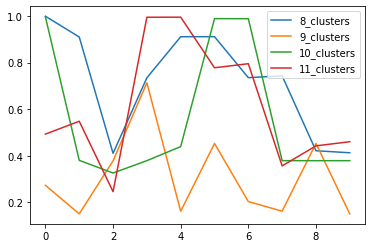

In [57]:
for key in list_score.keys() : 
    plt.plot(list(i for i in range(10)),list_score[key])
plt.legend(list_score.keys())
plt.show()

<a class="anchor" id="4"></a>
# **4. Etude de la stabilité dans le temps** 

[Table des matières](#0.1)


<a class="anchor" id="4.1"></a>
# **4.1 Etude pour 10 clusters** 

[Table des matières](#0.1)


In [17]:
data.Recency.describe()

count    92742.000000
mean       237.759074
std        152.577851
min          1.000000
25%        114.000000
50%        219.000000
75%        346.000000
max        695.000000
Name: Recency, dtype: float64

In [18]:
data_study= data[data['Recency']>360]
data_study.Recency.describe()

count    21240.000000
mean       460.161676
std         67.748238
min        361.000000
25%        403.000000
50%        453.000000
75%        510.000000
max        695.000000
Name: Recency, dtype: float64

In [29]:
scaler_old = StandardScaler()
scaler_old.fit(data_study)
X_scaled_old = scaler_old.transform(data) 
kmeans_old_10 = KMeans(n_clusters=10, random_state=1)          
kmeans_old_10.fit(X_scaled_old)
kmeans_old_9 = KMeans(n_clusters=9, random_state=1)          
kmeans_old_9.fit(X_scaled_old)

KMeans(n_clusters=9, random_state=1)

In [30]:
list_score_time = {'8_clusters':[],'9_clusters':[],'10_clusters':[],'11_clusters':[]}
for i in range (12) :
    for key in range(list_score_time.keys())
    data_test = data[data['Recency']>360-30*i]
    scaler_new = StandardScaler()
    scaler_new.fit(data_test)
    X_scaled_new = scaler_new.transform(data) 
    kmeans_new_10 = KMeans(n_clusters=10, random_state=1)          
    kmeans_new_10.fit(X_scaled_new)
    kmeans_new_9 = KMeans(n_clusters=9, random_state=1)          
    kmeans_new_9.fit(X_scaled_new)
    X_scaled_older = scaler_old.transform(data_test)
    kmeans_old_9.predict(X_scaled_older)
    list_score_time_9.append(adjusted_rand_score(kmeans_new_9.labels_,kmeans_old_9.labels_))
    kmeans_old_10.predict(X_scaled_older)
    list_score_time_10.append(adjusted_rand_score(kmeans_new_10.labels_,kmeans_old_10.labels_))
list_score_time_10,list_score_time_9


([1.0,
  0.8021440954045449,
  0.7781599096213514,
  0.5888495993738266,
  0.41270369284011965,
  0.40055818990518244,
  0.39906740657767104,
  0.3192646545621511,
  0.3396293733121071,
  0.3860170844938203,
  0.40814503211211817,
  0.3146935182595958],
 [1.0,
  0.8285369057480014,
  0.8136447361997358,
  0.3802444594587291,
  0.37590964391277626,
  0.3704871884887906,
  0.3470916394780542,
  0.3631282321694593,
  0.358722672560994,
  0.37965755937986473,
  0.3522626583868524,
  0.37251432136730994])

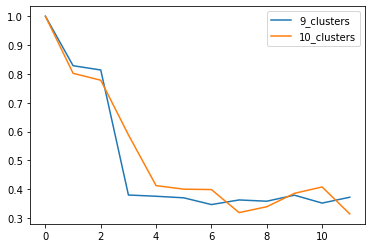

In [32]:
n_months = list(i for i in range(12))
plt.plot(n_months,list_score_time_9)
plt.plot(n_months,list_score_time_10)
plt.legend(["9_clusters","10_clusters"])
plt.show()